# Práctica 5. Modelos lineales y correlación

## Objetivo

Analizar la relación entre la interacción que reciben las recetas y su calificación promedio. Se agregan las reseñas por receta, se ajusta una regresión lineal múltiple para predecir las estrellas promedio y se evalúa su capacidad predictiva con el coeficiente de determinación $R^2$ en un conjunto de prueba.

**Unidad de análisis:** una receta. La variable objetivo es `promedio_estrellas`; los predictores son el número de reseñas, los votos positivos y negativos, las respuestas y el `best_score` promedio. No se utiliza la calificación como predictor para evitar fuga de información.


## 1. Librerías y carga del conjunto de datos

El conjunto de datos se carga desde `Practica 1/dataset_limpio.csv`, dentro de la carpeta del proyecto `MINERIA DE DATOS`. Asegúrate de guardar ahí el archivo antes de ejecutar esta celda; si no se encuentra o está vacío, el notebook mostrará un error.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)

directorio_proyecto = Path.cwd()
if directorio_proyecto.name.lower() == "practica 5":
    directorio_proyecto = directorio_proyecto.parent

ruta_csv = directorio_proyecto / "Practica 1" / "dataset_limpio.csv"

if not ruta_csv.is_file() or ruta_csv.stat().st_size == 0:
    raise FileNotFoundError(
        f"No se encontró un dataset_limpio.csv válido en {ruta_csv}. "
        "Guarda el archivo en MINERIA DE DATOS/Practica 1."
    )

df = pd.read_csv(ruta_csv)
print(f"Archivo: {ruta_csv}")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
display(df.head())

FileNotFoundError: No se encontró un dataset_limpio.csv válido en c:\Users\leoen\Documents\MINERIA DE DATOS\Practica 1\dataset_limpio.csv. Guarda el archivo en MINERIA DE DATOS/Practica 1.

## 2. Preparación y agregación por receta

Cada fila del archivo representa un comentario. Se agrupan los comentarios por receta para que cada observación del modelo represente una receta, igual que en el análisis de correlación de la práctica anterior. Las variables se convierten a formato numérico y se excluyen observaciones incompletas para el ajuste.

In [2]:
columnas_requeridas = {
    "recipe_number", "recipe_code", "recipe_name", "comment_id", "stars",
    "thumbs_up", "thumbs_down", "reply_count", "best_score",
}
faltantes = columnas_requeridas.difference(df.columns)
if faltantes:
    raise ValueError(f"Faltan columnas requeridas en el CSV: {sorted(faltantes)}")

columnas_numericas = ["stars", "thumbs_up", "thumbs_down", "reply_count", "best_score"]
for columna in columnas_numericas:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

tabla_recetas = (
    df.groupby(["recipe_number", "recipe_code", "recipe_name"], as_index=False)
    .agg(
        numero_resenas=("comment_id", "count"),
        promedio_estrellas=("stars", "mean"),
        total_me_gusta=("thumbs_up", "sum"),
        total_no_me_gusta=("thumbs_down", "sum"),
        total_respuestas=("reply_count", "sum"),
        promedio_best_score=("best_score", "mean"),
    )
)

predictores = [
    "numero_resenas", "total_me_gusta", "total_no_me_gusta",
    "total_respuestas", "promedio_best_score",
]
objetivo = "promedio_estrellas"
datos_modelo = tabla_recetas[[*predictores, objetivo]].replace([np.inf, -np.inf], np.nan).dropna()

if len(datos_modelo) < 5:
    raise ValueError(f"Se necesitan al menos 5 recetas completas; solo hay {len(datos_modelo)}.")

print(f"Recetas agregadas: {len(tabla_recetas)}")
print(f"Recetas completas incluidas en el modelo: {len(datos_modelo)}")
display(tabla_recetas.head())

Recetas agregadas: 100
Recetas completas incluidas en el modelo: 100


,recipe_number,recipe_code,recipe_name,numero_resenas,promedio_estrellas,total_me_gusta,total_no_me_gusta,total_respuestas,promedio_best_score
0,1,14299,Creamy White Chili,654,4.452599,332,145,10,130.729358
1,2,3309,Best Ever Banana Bread,509,4.587426,163,66,5,126.222004
2,3,2832,Cheeseburger Soup,725,4.576552,734,488,16,136.362759
3,4,17826,Amish Breakfast Casserole,338,4.526627,971,328,3,191.952663
4,5,42386,Pumpkin Spice Cupcakes with Cream Cheese Frosting,197,4.461929,26,13,0,111.751269


## 3. Correlación entre variables

La correlación de Pearson describe la fuerza y dirección de la relación lineal entre pares de variables. Un valor cercano a 1 indica una asociación positiva, uno cercano a -1 una asociación negativa y uno cercano a 0 una asociación lineal débil. La correlación por sí sola no implica causalidad.

,numero_resenas,total_me_gusta,total_no_me_gusta,total_respuestas,promedio_best_score,promedio_estrellas
numero_resenas,1.000,0.427,0.392,0.506,-0.155,0.190
total_me_gusta,0.427,1.000,0.890,0.596,0.666,0.119
total_no_me_gusta,0.392,0.890,1.000,0.617,0.600,0.085
total_respuestas,0.506,0.596,0.617,1.000,0.344,0.061
promedio_best_score,-0.155,0.666,0.600,0.344,1.000,0.106
promedio_estrellas,0.190,0.119,0.085,0.061,0.106,1.000


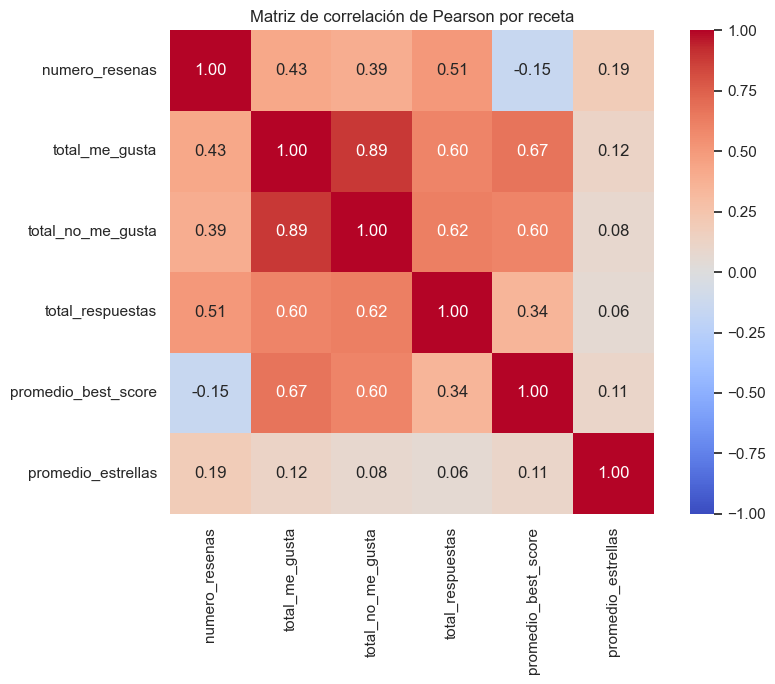

In [3]:
correlaciones = datos_modelo.corr(method="pearson")
display(correlaciones.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    correlaciones, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    vmin=-1, vmax=1, square=True, ax=ax,
)
ax.set_title("Matriz de correlación de Pearson por receta")
plt.tight_layout()
plt.show()

## 4. Ajuste del modelo lineal

Se reserva el 20 % de las recetas para prueba. La partición aleatoria con semilla fija permite reproducir los resultados. El modelo se ajusta únicamente con el conjunto de entrenamiento; las métricas principales se calculan sobre recetas que no participaron en el ajuste.

In [4]:
X = datos_modelo[predictores]
y = datos_modelo[objetivo]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

r2_prueba = r2_score(y_test, y_pred)
r2_entrenamiento = modelo.score(X_train, y_train)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Recetas en entrenamiento: {len(X_train)}")
print(f"Recetas en prueba: {len(X_test)}")
print(f"R² en entrenamiento: {r2_entrenamiento:.4f}")
print(f"R² en prueba:        {r2_prueba:.4f}")
print(f"MAE en prueba:       {mae:.4f} estrellas")
print(f"RMSE en prueba:      {rmse:.4f} estrellas")

coeficientes = pd.Series(modelo.coef_, index=predictores, name="coeficiente")
print(f"\nIntercepto: {modelo.intercept_:.4f}")
display(coeficientes.to_frame().round(6))

Recetas en entrenamiento: 80
Recetas en prueba: 20
R² en entrenamiento: 0.0839
R² en prueba:        0.0573
MAE en prueba:       0.2079 estrellas
RMSE en prueba:      0.2775 estrellas

Intercepto: 3.5597


,coeficiente
numero_resenas,0.001387
total_me_gusta,-0.000278
total_no_me_gusta,-0.000507
total_respuestas,-0.014749
promedio_best_score,0.003742


## 5. Gráficas de diagnóstico

La primera gráfica compara las predicciones con las calificaciones observadas: cuanto más cerca estén los puntos de la diagonal, mejores son las predicciones. La segunda revisa los errores (residuales) frente a las predicciones; un patrón marcado puede indicar que la relación no queda bien descrita por un modelo lineal.

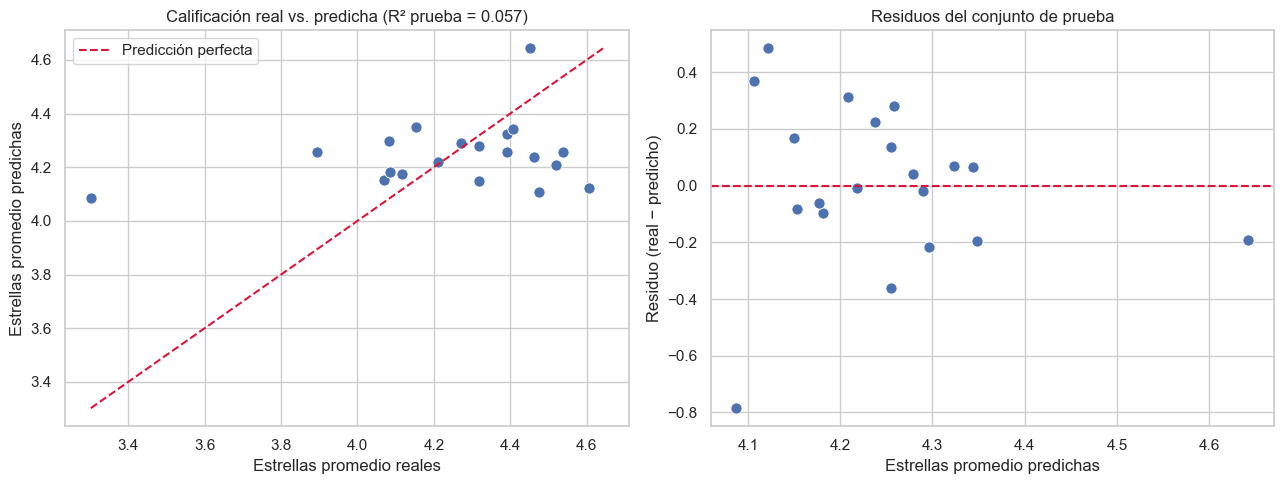

In [5]:
residuos = y_test.to_numpy() - y_pred
limite_inferior = min(y_test.min(), y_pred.min())
limite_superior = max(y_test.max(), y_pred.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=y_test, y=y_pred, s=65, ax=axes[0])
axes[0].plot(
    [limite_inferior, limite_superior], [limite_inferior, limite_superior],
    color="crimson", linestyle="--", label="Predicción perfecta",
)
axes[0].set(
    title=f"Calificación real vs. predicha (R² prueba = {r2_prueba:.3f})",
    xlabel="Estrellas promedio reales", ylabel="Estrellas promedio predichas",
)
axes[0].legend()

sns.scatterplot(x=y_pred, y=residuos, s=65, ax=axes[1])
axes[1].axhline(0, color="crimson", linestyle="--")
axes[1].set(
    title="Residuos del conjunto de prueba",
    xlabel="Estrellas promedio predichas", ylabel="Residuo (real − predicho)",
)

plt.tight_layout()
plt.show()

## 6. Relación individual entre predictores y calificación

Estos diagramas de dispersión muestran las asociaciones bivariadas de cada predictor con las estrellas promedio. La línea es una tendencia lineal visual; el modelo múltiple, en cambio, estima el efecto de cada predictor considerando simultáneamente los demás.

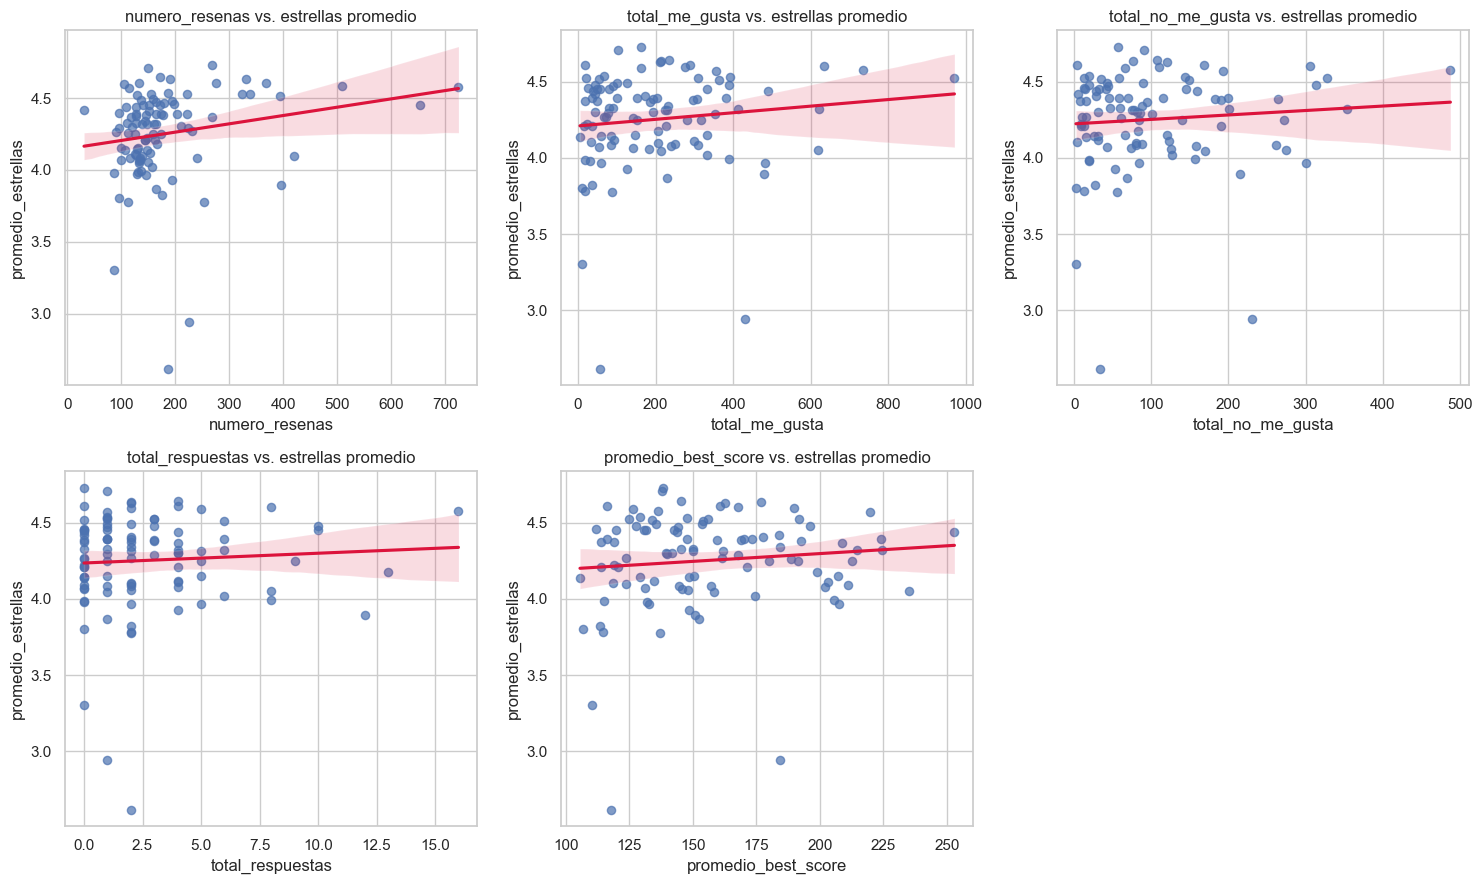

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, predictor in zip(axes.flat, predictores):
    sns.regplot(
        data=datos_modelo, x=predictor, y=objetivo, ax=ax,
        scatter_kws={"alpha": 0.7, "s": 35}, line_kws={"color": "crimson"},
    )
    ax.set_title(f"{predictor} vs. estrellas promedio")

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Interpretación y conclusiones

- **$R^2$ de prueba:** representa la proporción de variabilidad de las estrellas promedio explicada por el modelo en recetas no utilizadas para entrenar. Un valor cercano a 1 indica mayor capacidad explicativa; cercano a 0, capacidad limitada. Puede ser negativo si predice peor que usar el promedio del conjunto de prueba.
- **MAE:** error absoluto medio expresado en estrellas, útil para interpretar el tamaño típico del error.
- **RMSE:** penaliza con mayor peso los errores grandes y también se expresa en estrellas.
- Los coeficientes describen la asociación lineal estimada al mantener constantes los otros predictores; no prueban efectos causales.

Los valores numéricos y las gráficas se generan al ejecutar el notebook. Las conclusiones deben considerar el $R^2$ obtenido en prueba y los patrones de los residuos; no debe interpretarse el $R^2$ de entrenamiento como evidencia suficiente de generalización.